<a href="https://colab.research.google.com/github/Rodrigue-123-Rondy/ALGORITHME-NUEE-DYNAMIQUE/blob/Notebook/NUEE_DYNAMIQUE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Taille du jeu de données Iris : (150, 2)
Convergence atteinte à l'itération 16


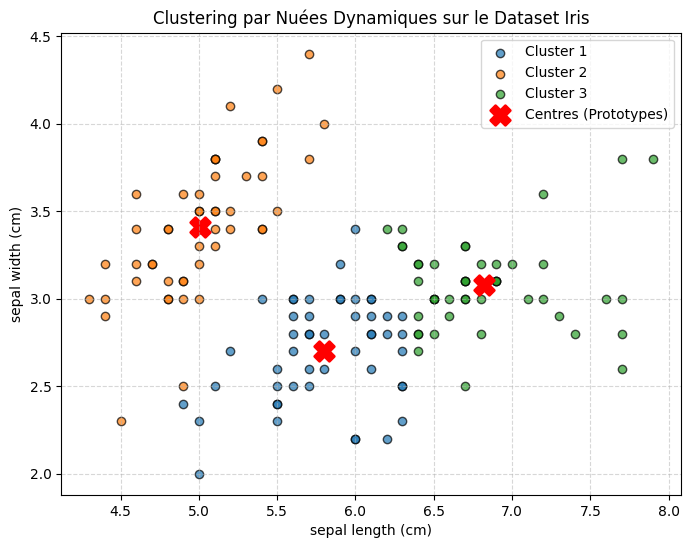

Graphique sauvegardé sous : resultat_nuees_dynamiques.png


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

# ---------------------------------------------------------
# 1. Chargement et préparation du Dataset Iris
# --------------------------------------------------------
iris = load_iris()
# On prend 2 variables (Longueur et Largeur des sépales) pour la visualisation 2D
X = iris.data[:, :2]
feature_names = iris.feature_names[:2]

print("Taille du jeu de données Iris :", X.shape)

# ---------------------------------------------------------
# 2. Implémentation des Nuées Dynamiques (K-Means) From Scratch
# --h-------------------------------------------------------
class NueesDynamiques:
    def __init__(self, k=3, max_iter=100, tol=1e-4):
        self.k = k
        self.max_iter = max_iter
        self.tol = tol
        self.centres = None

    def fit(self, X):
        np.random.seed(42) # Pour garantir la répétabilité des résultats

        # Étape 1 : Initialisation aléatoire des centres (prototypes)
        indices = np.random.choice(len(X), self.k, replace=False)
        self.centres = X[indices]

        for i in range(self.max_iter):
            # Étape 2 : Affectation des points au centre le plus proche
            distances = np.array([np.linalg.norm(X - c, axis=1) for c in self.centres])
            labels = np.argmin(distances, axis=0)

            # Étape 3 : Mise à jour des centres (calcul du centre de gravité)
            nouveaux_centres = np.array([X[labels == j].mean(axis=0) for j in range(self.k)])

            # Étape 4 : Test de convergence
            deplacement = np.linalg.norm(nouveaux_centres - self.centres)
            if deplacement < self.tol:
                print(f"Convergence atteinte à l'itération {i + 1}")
                break

            self.centres = nouveaux_centres

        return labels

# ---------------------------------------------------------
# 3. Exécution de l'algorithme (avec K=3)
# ---------------------------------------------------------
k = 3
model = NueesDynamiques(k=k)
labels = model.fit(X)

# ---------------------------------------------------------
# 4. Visualisation et sauvegarde des résultats
# ---------------------------------------------------------
plt.figure(figsize=(8, 6))

# Affichage des points colorés par cluster
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
for j in range(k):
    cluster_points = X[labels == j]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1],
                c=colors[j], label=f'Cluster {j+1}', alpha=0.7, edgecolors='k')

# Affichage des centres de gravité finaux
plt.scatter(model.centres[:, 0], model.centres[:, 1],
            c='red', marker='X', s=200, linewidths=2, label='Centres (Prototypes)')

plt.xlabel(feature_names[0])
plt.ylabel(feature_names[1])
plt.title("Clustering par Nuées Dynamiques sur le Dataset Iris")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

# Sauvegarde de la figure pour le rapport LaTeX
plt.savefig("resultat_nuees_dynamiques.png", dpi=300, bbox_inches='tight')
plt.show()

print("Graphique sauvegardé sous : resultat_nuees_dynamiques.png")